lambda = 0.5
c = 1.4715177646857693
Theoretical acceptance rate = 0.6795704571147613
Empirical acceptance fraction = 0.6820351930159596
Mean time per accepted sample = 1.8638417008332908e-06 seconds
Mean time per accepted sample = 1.8638417008332908 microseconds


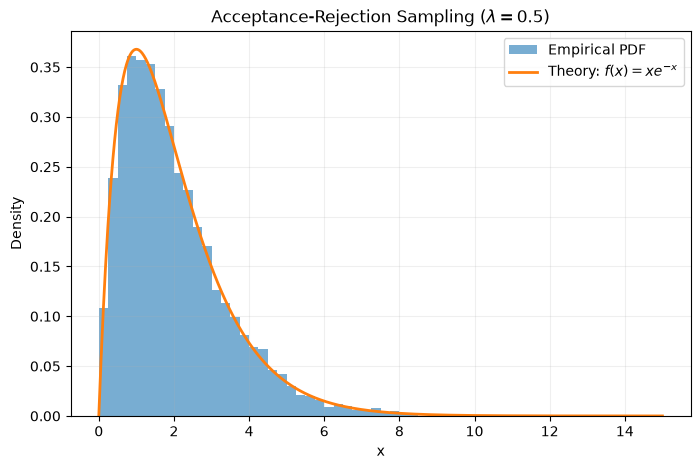


lambda = 0.2
c = 2.2992465073215143
Theoretical acceptance rate = 0.4349250925534473
Empirical acceptance fraction = 0.43875043875043873
Mean time per accepted sample = 1.2673333985731005e-06 seconds
Mean time per accepted sample = 1.2673333985731006 microseconds


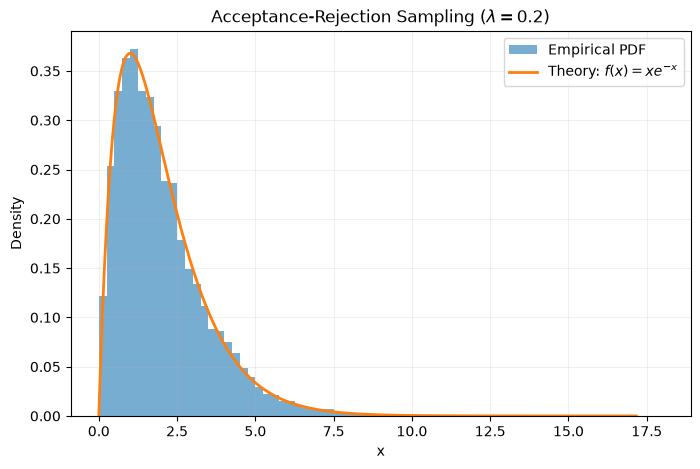

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os

N = 10**4
rng = np.random.default_rng(2026)


def acceptance_rejection(lam, N):
    # Envelope constant
    c = 1 / (lam * (1 - lam) * np.e)

    samples = []
    proposals = 0

    start = time.perf_counter()

    while len(samples) < N:
        # Sample X from Exp(lambda) using inverse transform
        U1 = rng.random()
        X = -np.log(U1) / lam

        # Acceptance test
        U2 = rng.random()

        f = X * np.exp(-X)
        g = lam * np.exp(-lam * X)

        if U2 < f / (c * g):
            samples.append(X)

        proposals += 1

    elapsed = time.perf_counter() - start

    samples = np.array(samples)

    # Empirical acceptance fraction
    empirical_acceptance = N / proposals

    # Mean time per accepted sample
    mean_time = elapsed / N

    return samples, c, empirical_acceptance, mean_time


# lambda = 0.5

samples_05, c_05, acc_05, time_05 = acceptance_rejection(0.5, N)

print("======================================")
print("lambda = 0.5")
print("======================================")
print("c =", c_05)
print("Theoretical acceptance rate =", 1 / c_05)
print("Empirical acceptance fraction =", acc_05)
print("Mean time per accepted sample =", time_05, "seconds")
print("Mean time per accepted sample =", time_05 * 1e6, "microseconds")


# Plot
bin_width = 0.25
bins_05 = np.arange(0, np.ceil(samples_05.max()) + bin_width, bin_width)

plt.figure(figsize=(8, 5))
plt.hist(
    samples_05,
    bins=bins_05,
    density=True,
    alpha=0.6,
    label="Empirical PDF"
)

x = np.linspace(0, max(15, samples_05.max()), 1000)
f = x * np.exp(-x)

plt.plot(x, f, linewidth=2, label=r"Theory: $f(x)=xe^{-x}$")

plt.xlabel("x")
plt.ylabel("Density")
plt.title(r"Acceptance-Rejection Sampling ($\lambda=0.5$)")
plt.legend()
plt.grid(alpha=0.2)

plt.savefig(os.path.expanduser("~/Downloads/lambda_0.5_plot.pdf"), bbox_inches="tight")
plt.show()


# lambda = 0.2

samples_02, c_02, acc_02, time_02 = acceptance_rejection(0.2, N)

print("\n======================================")
print("lambda = 0.2")
print("======================================")
print("c =", c_02)
print("Theoretical acceptance rate =", 1 / c_02)
print("Empirical acceptance fraction =", acc_02)
print("Mean time per accepted sample =", time_02, "seconds")
print("Mean time per accepted sample =", time_02 * 1e6, "microseconds")


# Plot
bins_02 = np.arange(0, np.ceil(samples_02.max()) + bin_width, bin_width)

plt.figure(figsize=(8, 5))
plt.hist(
    samples_02,
    bins=bins_02,
    density=True,
    alpha=0.6,
    label="Empirical PDF"
)

x = np.linspace(0, max(15, samples_02.max()), 1000)
f = x * np.exp(-x)

plt.plot(x, f, linewidth=2, label=r"Theory: $f(x)=xe^{-x}$")

plt.xlabel("x")
plt.ylabel("Density")
plt.title(r"Acceptance-Rejection Sampling ($\lambda=0.2$)")
plt.legend()
plt.grid(alpha=0.2)
plt.savefig(os.path.expanduser("~/Downloads/lambda_0.2_plot.pdf"), bbox_inches="tight")
plt.show()
